# Numerical Experiments: 

This notebook contains code for running the numerical experiments for a convex and non-convex example. Everything is can be run on a CPU

In [8]:
%load_ext autoreload
%autoreload 2
import importlib
import sys
from pathlib import Path

import time

import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

# If needed, point this to a local clone of your project root.
# project_root = Path(".").resolve()
# if str(project_root) not in sys.path:
#     sys.path.insert(0, str(project_root))

from utils.geometry import (
    create_circle_constraints,
    create_left_crescent_constraints,
    create_right_crescent_constraints,
)
from utils.quadrature_jax import (
    center_of_mass_fixed_grid,
    lambda_func_fixed_grid,
)
from utils.plotting import plot_trajectory_general
# from utils.sde_solvers_jax import run_multiple_trajectories_sde

jax.config.update("jax_enable_x64", True)
print(f"JAX backend: {jax.default_backend()}")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
JAX backend: cpu


In [9]:
def generate_grid(t0, T, delta, kappa):
    """Generate a time grid with
    - constant step kappa on [t0, T-1],
    - geometric steps kappa/(1+kappa)^m on [T-1, T-delta].

    The total number of steps is n_constant + n_tail.
    """
    t0 = float(t0)
    T = float(T)
    delta = float(delta)
    kappa = float(kappa)

    t_end = T - delta
    if t_end <= t0:
        return jnp.array([t0], dtype=jnp.float64)

    t_switch = min(t_end, max(t0, T - 1.0))
    n_constant = max(0, int(jnp.floor((t_switch - t0) / kappa)))

    t_after_constant = t0 + n_constant * kappa
    n_tail = 0
    t_probe = t_after_constant
    while t_probe < t_end:
        delta_k = kappa / ((1.0 + kappa) ** (n_tail + 1))
        t_probe += delta_k
        n_tail += 1

    num_steps = n_constant + n_tail

    ts = [t0]
    for k in range(num_steps):
        if k < n_constant:
            delta_k = kappa
        else:
            delta_k = kappa / ((1.0 + kappa) ** (k - n_constant + 1))

        t_next = ts[-1] + delta_k
        ts.append(min(t_next, t_end))

    return jnp.array(ts, dtype=jnp.float64)

In [10]:
def _ddim_exponential_step(y0, t0, t1, drift_fn):
    """Single DDIM exponential-integrator step: y_{k+1} = e^dt y_k + (e^dt - 1) f(t_k, y_k)."""
    dt = t1 - t0
    f_val = drift_fn(t0, y0)
    exp_dt = jnp.exp(dt)
    exp_minus_one = jnp.expm1(dt)
    return exp_dt * y0 + exp_minus_one * f_val

In [11]:
def _ddpm_exponential_step(y0, t0, t1, drift_fn, diffusion_fn, key):
    """Single DDPM exponential-integrator step matching the ExponentialDDPM update rule."""
    dt = t1 - t0
    f_val = drift_fn(t0, y0)
    g_val = diffusion_fn(t0, y0)

    exp_dt = jnp.exp(dt)
    exp_minus_one = jnp.expm1(dt)
    

    normal = jax.random.normal(key, shape=y0.shape, dtype=y0.dtype)
    diffusion_increment = jnp.sqrt(jnp.maximum(exp_minus_one, 0.0)) * (g_val * normal)

    return (exp_dt * y0) + (exp_minus_one * f_val) + diffusion_increment

In [12]:
def drift_vector_field(t, y, T, gamma, eta, y_lowers, y_uppers, x_ranges, weights, n_x = 20, n_y = 20, regions=None):
        """This defines the nonlinar part of the DDIM ODE"""
        weights_jax = jnp.array(weights, dtype=jnp.float64)
        n_regions = len(weights_jax)
        gamma_jax = jnp.array(gamma, dtype=jnp.float64)
        cur_pos = y
        time_remaining = T - t
        lambda_term = jnp.exp(-time_remaining)
        sigma2_term = 1 - lambda_term**2

        coms_list = []
        for i in range(n_regions):
            coms_list.append(
                center_of_mass_fixed_grid(
                    cur_pos,
                    None if regions is not None else y_lowers[i],
                    None if regions is not None else y_uppers[i],
                    None if regions is not None else x_ranges[i],
                    time_remaining,
                    n_x,
                    n_y,
                    region=None if regions is None else regions[i],
                )
            )
        coms = jnp.stack(coms_list)
        diffs = coms - (cur_pos / lambda_term)

        lambda_weights_list = []
        for i in range(n_regions):
            lambda_weights_list.append(
                lambda_func_fixed_grid(
                    cur_pos,
                    i,
                    time_remaining,
                    y_lowers,
                    y_uppers,
                    x_ranges,
                    weights_jax,
                    n_x,
                    n_y,
                    regions=regions,
                )
            )
        lambda_weights = jnp.array(lambda_weights_list)

        cur_diff = (gamma_jax * lambda_term / sigma2_term) * diffs[eta]
        average_diff = ((gamma_jax - 1) * lambda_term / sigma2_term) * jnp.sum(
            lambda_weights[:, jnp.newaxis] * diffs, axis=0
        )
        return cur_diff - average_diff

In [13]:
def DDIM_solver_exponential(
    gamma,
    eta,
    y_lowers,
    y_uppers,
    x_ranges,
    weights,
    initial_condition,
    T,
    ts,
    n_x=20,
    n_y=20,
    max_steps=16000,
    regions=None,
):
    """Solve one guided DDIM ODE trajectory using a JIT-compiled exponential scan."""
    ts_jax = jnp.array(ts, dtype=jnp.float64)
    n_steps = int(ts_jax.shape[0] - 1)
    if n_steps > max_steps:
        raise ValueError(f"Number of steps ({n_steps}) exceeds max_steps ({max_steps}).")

    t_prev = ts_jax[:-1]
    dt = ts_jax[1:] - ts_jax[:-1]
    exp_dt = jnp.exp(dt)
    exp_minus_one = jnp.expm1(dt)

    drift_fn = lambda t, y: drift_vector_field(
        t, y, T, gamma, eta, y_lowers, y_uppers, x_ranges, weights, n_x, n_y, regions=regions
    )

    @jax.jit
    def _integrate(y0, t_prev, exp_dt, exp_minus_one):
        def step(y, inputs):
            t_k, a_k, b_k = inputs
            f_val = drift_fn(t_k, y)
            y_next = a_k * y + b_k * f_val
            return y_next, y_next

        _, ys_tail = jax.lax.scan(step, y0, (t_prev, exp_dt, exp_minus_one))
        return jnp.concatenate([y0[jnp.newaxis, :], ys_tail], axis=0)

    y0 = jnp.array(initial_condition, dtype=jnp.float64)
    return _integrate(y0, t_prev, exp_dt, exp_minus_one)

In [14]:
def DDPM_solver_exponential(
    gamma,
    eta,
    y_lowers,
    y_uppers,
    x_ranges,
    weights,
    initial_condition,
    T,
    ts,
    random_key,
    n_x=20,
    n_y=20,
    max_steps=16000,
    regions=None,
):
    """Solve one guided DDPM SDE trajectory using a JIT-compiled exponential scan."""
    ts_jax = jnp.array(ts, dtype=jnp.float64)
    n_steps = int(ts_jax.shape[0] - 1)
    if n_steps > max_steps:
        raise ValueError(f"Number of steps ({n_steps}) exceeds max_steps ({max_steps}).")

    t_prev = ts_jax[:-1]
    dt = ts_jax[1:] - ts_jax[:-1]
    exp_dt = jnp.exp(dt)
    exp_minus_one = jnp.expm1(dt)
    sqrt_exp_minus_one = jnp.sqrt(jnp.maximum(exp_minus_one, 0.0))

    drift_fn = lambda t, y: 2 * drift_vector_field(
        t, y, T, gamma, eta, y_lowers, y_uppers, x_ranges, weights, n_x, n_y, regions=regions
    )
    diffusion_fn = lambda t, y: jnp.sqrt(2.0) * jnp.ones_like(y)

    y0 = jnp.array(initial_condition, dtype=jnp.float64)
    normals = jax.random.normal(
        random_key, shape=(n_steps,) + y0.shape, dtype=y0.dtype
    )

    @jax.jit
    def _integrate(y0, t_prev, exp_dt, exp_minus_one, sqrt_exp_minus_one, normals):
        def step(y, inputs):
            t_k, a_k, b_k, sqrt_b_k, z_k = inputs
            f_val = drift_fn(t_k, y)
            g_val = diffusion_fn(t_k, y)
            y_next = (a_k * y) + (b_k * f_val) + (sqrt_b_k * (g_val * z_k))
            return y_next, y_next

        _, ys_tail = jax.lax.scan(
            step, y0, (t_prev, exp_dt, exp_minus_one, sqrt_exp_minus_one, normals)
        )
        return jnp.concatenate([y0[jnp.newaxis, :], ys_tail], axis=0)

    return _integrate(y0, t_prev, exp_dt, exp_minus_one, sqrt_exp_minus_one, normals)

In [15]:
def _run_multiple_trajectories_core(
    gammas,
    etas,
    initial_conditions,
    ts,
    solve_and_evaluate_fn,
    with_keys=False,
    master_key=jax.random.PRNGKey(41),
):
    """Shared batched runner for ODE/SDE trajectory generation."""
    gammas_jax = jnp.array(gammas, dtype=jnp.float64)
    etas_jax = jnp.array(etas, dtype=jnp.int64)
    initial_conditions_jax = jnp.array(initial_conditions, dtype=jnp.float64)
    ts_jax = jnp.array(ts, dtype=jnp.float64)

    num_gammas = gammas_jax.shape[0]
    num_etas = etas_jax.shape[0]
    num_initial_conds = initial_conditions_jax.shape[0]

    G, E, I_idx = jnp.meshgrid(gammas_jax, etas_jax, jnp.arange(num_initial_conds), indexing="ij")
    flat_gammas = G.ravel()
    flat_etas = E.ravel()
    flat_init_conds = initial_conditions_jax[I_idx.ravel()]

    if with_keys:
        flat_keys = jax.random.split(master_key, flat_gammas.shape[0])
        flat_results = jax.vmap(solve_and_evaluate_fn, in_axes=(0, 0, 0, 0))(
            flat_keys, flat_gammas, flat_etas, flat_init_conds
        )
    else:
        flat_results = jax.vmap(solve_and_evaluate_fn, in_axes=(0, 0, 0))(
            flat_gammas, flat_etas, flat_init_conds
        )

    if flat_results.ndim == 2:
        flat_results = flat_results[:, jnp.newaxis, :]

    n_samples_out = flat_results.shape[1]
    state_dim = flat_results.shape[2]
    all_trajectories = flat_results.reshape(
        (num_gammas, num_etas, num_initial_conds, n_samples_out, state_dim)
    )

    all_trajectories_np = np.array(all_trajectories)
    t_eval_np = np.array(ts_jax)
    results_dict = {}

    for i_g, g in enumerate(gammas):
        for i_e, e in enumerate(etas):
            for i_t in range(len(initial_conditions)):
                traj = all_trajectories_np[i_g, i_e, i_t]
                results_dict[(float(g), int(e), i_t)] = (traj[:, 0], traj[:, 1], t_eval_np)

    return results_dict


def run_multiple_ODEs(
    gammas,
    etas,
    y_lowers,
    y_uppers,
    x_ranges,
    weights,
    initial_conditions,
    T,
    ts,
    endpoint_only=False,
    ode_solver=DDIM_solver_exponential,
    n_x=20,
    n_y=20,
    max_steps=16000,
    n_samples=100,
    regions=None,
):
    """Runs the DDIM ODE with exponential integrator (no diffrax)."""
    _ = n_samples
    weights_jax = jnp.array(weights, dtype=jnp.float64)

    def solve_and_evaluate(gamma, eta, init_cond):
        traj = ode_solver(
            gamma=gamma,
            eta=eta,
            y_lowers=y_lowers,
            y_uppers=y_uppers,
            x_ranges=x_ranges,
            weights=weights_jax,
            initial_condition=init_cond,
            T=T,
            ts=ts,
            n_x=n_x,
            n_y=n_y,
            max_steps=max_steps,
            regions=regions,
        )
        if endpoint_only:
            return traj[-1]
        return traj

    return _run_multiple_trajectories_core(
        gammas=gammas,
        etas=etas,
        initial_conditions=initial_conditions,
        ts=ts,
        solve_and_evaluate_fn=solve_and_evaluate,
        with_keys=False,
    )

In [16]:
def run_multiple_SDEs(
    gammas,
    etas,
    y_lowers,
    y_uppers,
    x_ranges,
    weights,
    initial_conditions,
    T,
    ts,
    endpoint_only = False,
    sde_solver=DDPM_solver_exponential,
    n_x=20,
    n_y=20,
    max_steps=16000,
    n_samples=100,
    master_key=jax.random.PRNGKey(41),
    regions=None,
):
    """Runs the DDPM SDE with exponential integrator (no diffrax)."""
    _ = n_samples
    solver_fn = sde_solver

    weights_jax = jnp.array(weights, dtype=jnp.float64)

    def solve_and_evaluate(key, gamma, eta, init_cond):
        traj = solver_fn(
            gamma=gamma,
            eta=eta,
            y_lowers=y_lowers,
            y_uppers=y_uppers,
            x_ranges=x_ranges,
            weights=weights_jax,
            initial_condition=init_cond,
            T=T,
            ts=ts,
            random_key=key,
            n_x=n_x,
            n_y=n_y,
            max_steps=max_steps,
            regions=regions,
        )
        if endpoint_only:
            return traj[-1]
        return traj

    return _run_multiple_trajectories_core(
        gammas=gammas,
        etas=etas,
        initial_conditions=initial_conditions,
        ts=ts,
        solve_and_evaluate_fn=solve_and_evaluate,
        with_keys=True,
        master_key=master_key,
    )

## 1) Convex Case: ODE + SDE Trajectories
### This section contains visualization for Figure 3 and Figure 4 in the paper 

In [19]:
T = 5
delta = 0.001
weights = np.array([1/3, 1/3, 1/3], dtype=float)

is_region0, y_lower0, y_upper0, x_range0 = create_circle_constraints(center=jnp.array([-1.5, 0.5]), radius=0.7)
is_region1, y_lower1, y_upper1, x_range1 = create_circle_constraints(center=jnp.array([0.2, 3.0]), radius=1.2)
is_region2, y_lower2, y_upper2, x_range2 = create_circle_constraints(center=jnp.array([2.5, -0.5]), radius=1.5)

y_lowers = [y_lower0, y_lower1, y_lower2]
y_uppers = [y_upper0, y_upper1, y_upper2]
x_ranges = [x_range0, x_range1, x_range2]

regions = [
    {"constraint": is_region0, "bbox": [x_range0[0], x_range0[1], -5.0, 5.0]},
    {"constraint": is_region1, "bbox": [x_range1[0], x_range1[1], -5.0, 5.0]},
    {"constraint": is_region2, "bbox": [x_range2[0], x_range2[1], -5.0, 5.0]},
]

region_constraints = [is_region0, is_region1, is_region2]
bounding_boxes = [r["bbox"] for r in regions]

initial_conditions = np.array([[-3.0, 3.0], [-1.0, -3.0], [0.0, 0.0], [2.0, -4.0], [5.0, -2.0]], dtype=float)
gammas = [1, 1.5, 2, 5]
etas = [0, 1]
eta_test = 1

In [20]:
# collect all results of ODEs, each with different kappas
results_ode_all_step = {} 

all_sol_ode_x = {} # x cooridattes of ODE solutiosn indexed by kappa
all_sol_ode_y = {}

for kappa in [0.1, 0.5]:
    ts = generate_grid(t0=0.0, T=T, delta=delta, kappa=kappa)
    results_ode = run_multiple_ODEs(
        gammas=gammas,
        etas=etas,
        y_lowers=y_lowers,
        y_uppers=y_uppers,
        x_ranges=x_ranges,
        weights=weights,
        initial_conditions=initial_conditions,
        T=T,
        ts=ts
    )
    all_sol_ode_x[kappa] = [results_ode[(gamma, 1, i)][0] for i in range(len(initial_conditions)) for gamma in gammas]
    all_sol_ode_y[kappa] = [results_ode[(gamma, 1, i)][1] for i in range(len(initial_conditions)) for gamma in gammas]
    results_ode_all_step[kappa] = results_ode

### Plotting

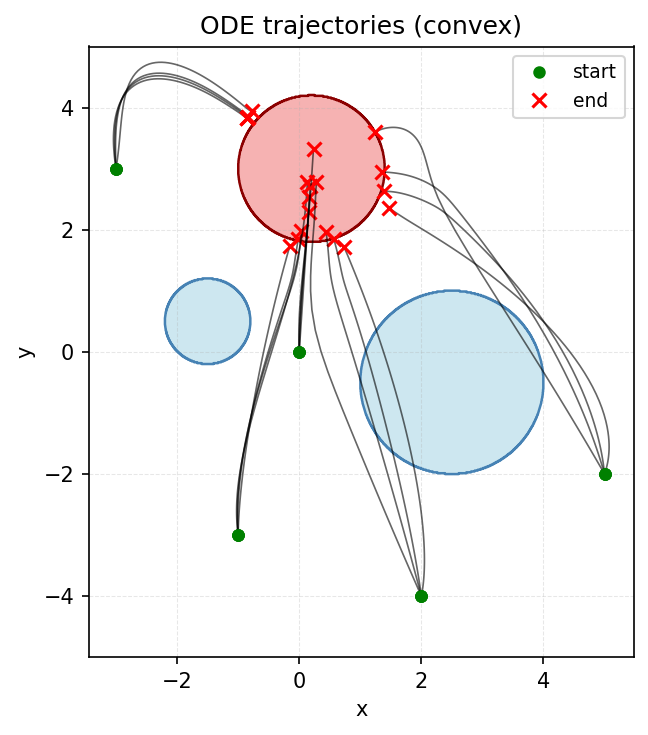

In [21]:
kappa_test = 0.1
fig, ax = plot_trajectory_general(all_sol_ode_x[kappa_test], all_sol_ode_y[kappa_test], regions, eta=eta_test, title="ODE trajectories (convex)")
plt.show()

In [22]:

rng = np.random.default_rng()

In [23]:
# SDE trajectories for the same initial conditions
results_all_step_sde = {}
all_sol_sde_x = {}
all_sol_sde_y = {}
for kappa in [0.1, 0.5]:
    ts = generate_grid(t0=0.0, T=T, delta=delta, kappa=kappa)
    results_sde = run_multiple_SDEs(
        gammas=gammas,
        etas=etas,
        y_lowers=y_lowers,
        y_uppers=y_uppers,
        x_ranges=x_ranges,
        weights=weights,
        initial_conditions=initial_conditions,
        T=T,
        sde_solver=DDPM_solver_exponential,
        ts=ts,
        n_samples=120,
        master_key=jax.random.key(rng.choice(np.arange(1, 100)))
    )
    all_sol_sde_x[kappa] = [results_sde[(gamma, 1, i)][0] for i in range(len(initial_conditions)) for gamma in gammas]
    all_sol_sde_y[kappa] = [results_sde[(gamma, 1, i)][1] for i in range(len(initial_conditions)) for gamma in gammas]
    results_all_step_sde[kappa] = results_sde

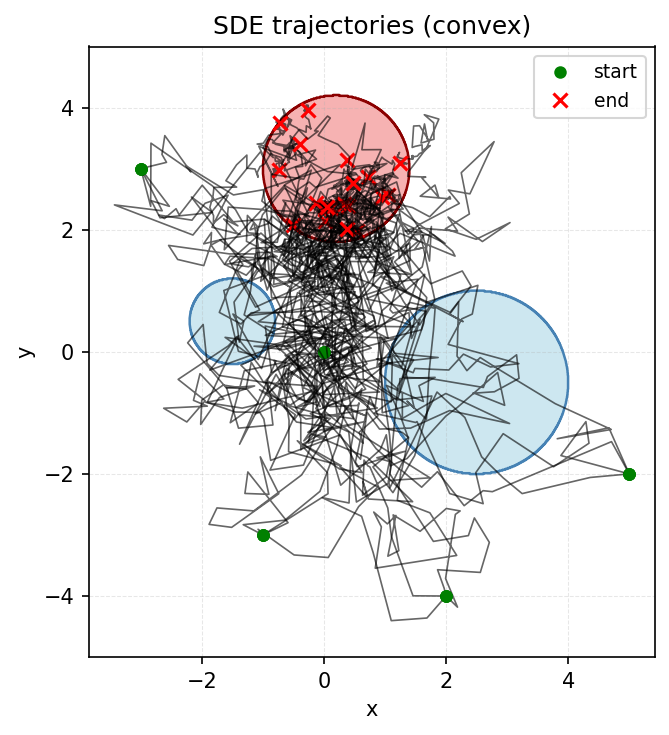

In [24]:
kappa_test = 0.1
fig, ax = plot_trajectory_general(all_sol_sde_x[kappa_test], all_sol_sde_y[kappa_test], regions, eta=eta_test, title="SDE trajectories (convex)")
plt.show()

## 2) Non-Convex Case: ODE + SDE Trajectories
### This section contains visualization for Figure 5 and Figure 6

In [ ]:
weights_nc = np.array([1/2, 1/2], dtype=float)

is_region1, y_lower1, y_upper1, x_range1 = create_left_crescent_constraints(
    center=jnp.array([2.0, 2.0]), radius_outer=1.5, radius_inner=1.0, offset_x=0.8
)
is_region2, y_lower2, y_upper2, x_range2 = create_right_crescent_constraints(
    center=jnp.array([-2.0, 3.0]), radius_outer=1.5, radius_inner=1.0, offset_x=0.8
)

y_lowers_nc = [y_lower1, y_lower2]
y_uppers_nc = [y_upper1, y_upper2]
x_ranges_nc = [x_range1, x_range2]

regions_nc = [
    {"constraint": is_region1, "bbox": [x_range1[0], x_range1[1], -5.0, 5.0]},
    {"constraint": is_region2, "bbox": [x_range2[0], x_range2[1], -5.0, 5.0]},
]

region_constraints_nc = [is_region1, is_region2]
bounding_boxes_nc = [r["bbox"] for r in regions_nc]

initial_conditions_nc = np.array([[-2.0, 2], [-1.5, -2], [1.5, 2], [2, -1.6]], dtype=float)
kappa = 0.1
T = 5
# ts = generate_grid(t0=0.0, T=T, delta=delta, kappa=kappa)
gammas_nc = [1, 1.5, 2, 5, 50]
etas_nc = [0, 1]
eta_test = 0

In [26]:
# ODE trajectories for the same initial conditions for different kappas
results_ode_all_step_nc = {}
all_sol_ode_x_nc = {}
all_sol_ode_y_nc = {}

for kappa in [0.1, 0.5]:
    ts = generate_grid(t0=0.0, T=T, delta=delta, kappa=kappa)
    results_ode_nc = run_multiple_ODEs(
        gammas=gammas_nc,
        etas=etas_nc,
        y_lowers=y_lowers_nc,
        y_uppers=y_uppers_nc,
        x_ranges=x_ranges_nc,
        weights=weights_nc,
        initial_conditions=initial_conditions_nc,
        T=T,
        ode_solver=DDIM_solver_exponential,
        ts=ts,
        n_samples=120,
        regions=regions_nc,
    )
    all_sol_ode_x_nc[kappa] = [results_ode_nc[(gamma, 0, i)][0] for i in range(len(initial_conditions_nc)) for gamma in [1]]
    all_sol_ode_y_nc[kappa] = [results_ode_nc[(gamma, 0, i)][1] for i in range(len(initial_conditions_nc)) for gamma in [1]]
    results_ode_all_step_nc[kappa] = results_ode_nc

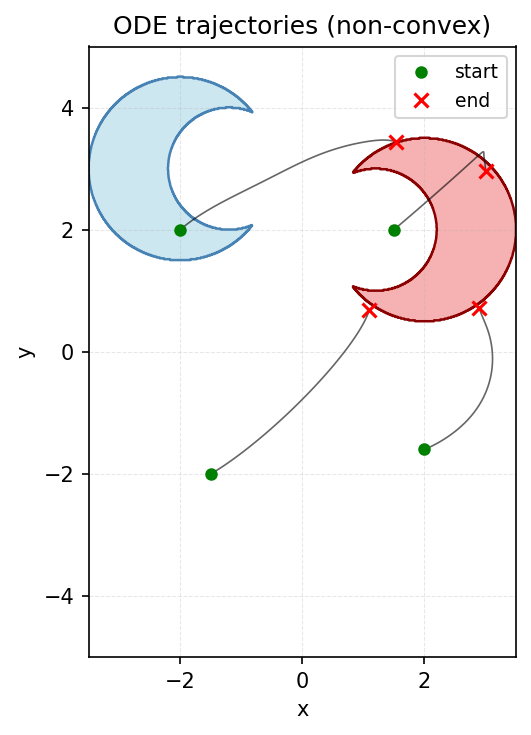

In [27]:

kappa_test = 0.1
fig, ax = plot_trajectory_general(
    all_sol_ode_x_nc[kappa_test], all_sol_ode_y_nc[kappa_test], regions_nc, eta=eta_test, title="ODE trajectories (non-convex)"
 )
plt.show()

In [28]:
# SDE trajectories for the same initial conditions
rng = np.random.default_rng()
results_all_step_sde_nc = {}
all_sol_sde_x_nc = {}
all_sol_sde_y_nc = {}
for kappa in [0.1, 0.5]:
    ts = generate_grid(t0=0.0, T=T, delta=delta, kappa=kappa)
    results_sde_nc = run_multiple_SDEs(
        gammas=gammas_nc,
        etas=etas_nc,
        y_lowers=y_lowers_nc,
        y_uppers=y_uppers_nc,
        x_ranges=x_ranges_nc,
        weights=weights_nc,
        initial_conditions=initial_conditions_nc,
        T=T,
        sde_solver=DDPM_solver_exponential,
        ts=ts,
        n_samples=120,
        master_key=jax.random.key(rng.choice(np.arange(41, 1000))),
        regions=regions_nc,
    )
    all_sol_sde_x_nc[kappa] = [results_sde_nc[(gamma, 0, i)][0] for i in range(len(initial_conditions_nc)) for gamma in [1.5]]
    all_sol_sde_y_nc[kappa] = [results_sde_nc[(gamma, 0, i)][1] for i in range(len(initial_conditions_nc)) for gamma in [1.5]]
    results_all_step_sde_nc[kappa] = results_sde_nc

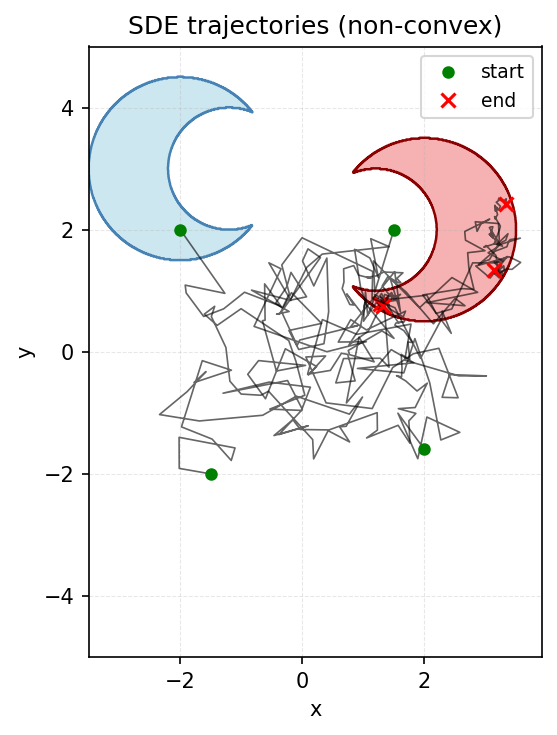

In [29]:

kappa_test = 0.1
fig, ax = plot_trajectory_general(
    all_sol_sde_x_nc[kappa_test], all_sol_sde_y_nc[kappa_test], regions_nc, eta=eta_test, title="SDE trajectories (non-convex)"
)
plt.show()